
# Entrega 2 – IA & ML
Tema: Classificação do status do cliente (`Active=1` vs `Inactive=2`) usando `Customer_semicolon.csv`  
Alunos: Leonardo Ferreira e Maria Kassandra_  
Disciplina: Inteligência Artificial & Machine Learning

---

## 1. Objetivo
Nesta entrega, treinaremos e compararemos **modelos de classificação** para prever o **status do cliente** (ativo ou inativo) a partir do dataset `Customer_semicolon.csv`.  
Seguindo o **padrão dos Colabs de aula**, faremos:
texto em itálico
1. Preparação e exploração do conjunto de dados (limpeza, engenharia de atributos, divisão treino/teste).  
2. Construção de **Pipelines** com `scikit-learn` (pré-processamento + modelo) – como visto em aula.  
3. Treinamento de **múltiplos algoritmos** e **comparação de métricas** (Accuracy, Precision, Recall, F1, ROC AUC).  
4. Um ensemble com **`VotingClassifier` (soft)** combinando 3 modelos para avaliar se há ganho.  
5. **Comentário detalhado** ao longo do código explicando as decisões e passos.

> **Observação:** Optamos pelo dataset **Customer** porque ele traz a variável-alvo `status` definida no kit: `Active = 1`, `Inactive = 2`.  
> Outras bases como `CampaignQueue` e `Campaign` também possuem um `status`, mas a semântica lá é de _estado do agendamento_ / _estado da campanha_. Como nosso dashboard toca em CRM e recorrência, faz sentido tentar **antecipar clientes que tendem a ficar inativos**.

In [1]:

# =========================
# IMPORTS (padrão de aula)
# =========================
import pandas as pd
import numpy as np

# Visualização (usaremos apenas matplotlib para manter compatibilidade)
import matplotlib.pyplot as plt

# Pré-processamento e Modelagem
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos clássicos explicados em aula
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, RocCurveDisplay
)

# Utilidades
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")



## 2. Carregamento dos dados

- O arquivo original foi fornecido como `Customer_semicolon.csv`. Ele é trazido do Github do nosso grupo.

In [12]:
# =========================
# ONDE ESTÁ O ARQUIVO?
# =========================
# Preferimos ler direto do GitHub (raw URL)
DATA_PATH = "https://raw.githubusercontent.com/2025-2-NCC5/Projeto3/refs/heads/main/documentos/Entrega%201/Customer_semicolon.csv"

# Leitura segura com separador ';'
# Tenta baixar do GitHub (requer internet)
df = pd.read_csv(DATA_PATH, sep=";")

print("Dimensão:", df.shape)
display(df.head())

Dimensão: (1000, 16)


,id,name,taxId,gender,dateOfBirth,status,externalCode,isEnriched,enrichedAt,enrichedBy,createdAt,createdBy,updatedAt,updatedBy,phone,email
0,1,Fernanda Duarte,207.463.819-13,O,05/10/1972,1,NaN,True,04/08/2024 02:29,franciscocarvalho,08/06/2024 02:29,pferreira,04/08/2024 02:29,wazevedo,"5,52193E+12",luigi67@hotmail.com
1,2,Matheus Jesus,46.792.503/0001-48,M,19/03/1962,2,NaN,False,NaN,NaN,29/12/2023 11:04,livia49,09/03/2024 11:04,ana-beatriz44,"5,55192E+12",otavio28@bol.com.br
2,3,João da Mota,594.173.682-73,F,20/10/1991,1,UZZPQK51,True,31/10/2023 02:50,calebe40,16/10/2023 02:50,lopesmaria-vitoria,31/10/2023 02:50,luiz-fernandopires,"5,56191E+12",eduardasantos@yahoo.com.br
3,4,Arthur Silveira,574.908.123-05,F,04/08/1952,1,NaN,True,07/07/2024 18:43,moraesluigi,04/12/2023 18:43,da-conceicaonoah,07/07/2024 18:43,vieiraguilherme,"5,58497E+12",jcosta@uol.com.br
4,5,Vicente Teixeira,937.825.104-88,NaN,04/02/1973,1,NaN,False,NaN,NaN,26/07/2024 06:52,ferreiramatheus,14/01/2025 06:52,goncalvesluna,"5,522E+12",oda-paz@ig.com.br



## 3. Exploração e limpeza rápida

Aqui fazemos:
- Conferência de colunas e tipos
- Conversão de colunas de datas para `datetime`
- Padronização de campos booleanos
- Checagem da variável-alvo `status` (1 = ativo, 2 = inativo)


In [3]:

# Colunas disponíveis
print("Colunas:", df.columns.tolist())

# Conversão de datas (fazemos tentativa em colunas que, pelo kit, costumam ser datas)
date_cols_guess = ["dateOfBirth", "enrichedAt", "createdAt", "updatedAt"]
for c in date_cols_guess:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Padronização de booleanos (isEnriched costuma vir como True/False)
if "isEnriched" in df.columns:
    df["isEnriched"] = (
        df["isEnriched"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"true": 1, "false": 0, "1": 1, "0": 0})
        .fillna(0)
        .astype(int)
    )

# Alvo: status (1=Active, 2=Inactive)
if "status" not in df.columns:
    raise ValueError("A coluna 'status' não está no CSV. Ajuste o alvo ou escolha outra base.")

print("\nDistribuição de 'status':")
print(df["status"].value_counts(dropna=False))


Colunas: ['id', 'name', 'taxId', 'gender', 'dateOfBirth', 'status', 'externalCode', 'isEnriched', 'enrichedAt', 'enrichedBy', 'createdAt', 'createdBy', 'updatedAt', 'updatedBy', 'phone', 'email']

Distribuição de 'status':
status
2    508
1    492
Name: count, dtype: int64



## 4. Engenharia de atributos

Criamos variáveis numéricas simples e interpretáveis:

- `idade` (em anos) a partir de `dateOfBirth`  
- `conta_dias` desde `createdAt` até hoje  
- `dias_desde_update` (se houver `updatedAt`)  
- `dias_desde_enriquecimento` (se houver `enrichedAt`)  
- `tem_codigo_externo` (se possui `externalCode`)  
- `qtd_letras_nome` (tamanho do nome – proxy de informação básica de cadastro)  


In [4]:

df_eng = df.copy()

# Funções auxiliares
def anos_entre(hoje, data):
    if pd.isna(data):
        return np.nan
    # diferença em dias / 365
    return (hoje - data).days / 365.25

def dias_entre(hoje, data):
    if pd.isna(data):
        return np.nan
    return (hoje - data).days

hoje = pd.Timestamp.today()

# idade
if "dateOfBirth" in df_eng.columns:
    df_eng["idade"] = df_eng["dateOfBirth"].apply(lambda d: anos_entre(hoje, d))
else:
    df_eng["idade"] = np.nan

# idade da conta (dias desde createdAt)
if "createdAt" in df_eng.columns:
    df_eng["conta_dias"] = df_eng["createdAt"].apply(lambda d: dias_entre(hoje, d))
else:
    df_eng["conta_dias"] = np.nan

# dias desde última atualização
if "updatedAt" in df_eng.columns:
    df_eng["dias_desde_update"] = df_eng["updatedAt"].apply(lambda d: dias_entre(hoje, d))
else:
    df_eng["dias_desde_update"] = np.nan

# dias desde enriquecimento
if "enrichedAt" in df_eng.columns:
    df_eng["dias_desde_enriquecimento"] = df_eng["enrichedAt"].apply(lambda d: dias_entre(hoje, d))
else:
    df_eng["dias_desde_enriquecimento"] = np.nan

# se possui externalCode
df_eng["tem_codigo_externo"] = df_eng.get("externalCode", pd.Series(index=df_eng.index)).notna().astype(int)

# tamanho do nome (se existir)
if "name" in df_eng.columns:
    df_eng["qtd_letras_nome"] = df_eng["name"].astype(str).str.len()
else:
    df_eng["qtd_letras_nome"] = np.nan

display(df_eng[["status","idade","conta_dias","dias_desde_update","dias_desde_enriquecimento","isEnriched","tem_codigo_externo","qtd_letras_nome"]].head())


,status,idade,conta_dias,dias_desde_update,dias_desde_enriquecimento,isEnriched,tem_codigo_externo,qtd_letras_nome
0,1,53.478439,452.0,572.0,572.0,1,0,15
1,2,NaN,NaN,423.0,NaN,0,0,13
2,1,NaN,NaN,NaN,NaN,1,1,12
3,1,73.566051,933.0,481.0,481.0,1,0,15
4,1,52.583162,NaN,NaN,NaN,0,0,16



## 5. Seleção de features & divisão treino/teste

- Alvo (`y`): `status`  
- Features (`X`): escolhemos colunas com maior disponibilidade e sentido de negócio.  
- Treino/Teste: 80/20 com estratificação para manter a proporção de classes, como visto em aula.


In [5]:

# Colunas que usaremos como entrada (numéricas e categóricas simples)
numericas = [
    "idade", "conta_dias", "dias_desde_update",
    "dias_desde_enriquecimento", "qtd_letras_nome"
]
categoricas = []

# Adicionamos 'isEnriched' e 'tem_codigo_externo' como numéricas binárias
numericas += ["isEnriched", "tem_codigo_externo"]

# Se existir 'gender', tratamos como categórica
if "gender" in df_eng.columns:
    categoricas.append("gender")

# Monta X e y
X = df_eng[numericas + categoricas].copy()
y = df_eng["status"].copy()

# Divisão treino/teste estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train:", X_train.shape, " | X_test:", X_test.shape)
print("Distribuição treino:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Distribuição teste:", y_test.value_counts(normalize=True).round(3).to_dict())


X_train: (800, 8)  | X_test: (200, 8)
Distribuição treino: {2: 0.507, 1: 0.492}
Distribuição teste: {2: 0.51, 1: 0.49}



## 6. Pré-processamento (Pipeline)

- Numéricas: `SimpleImputer(strategy="median")` + `StandardScaler()`  
- Categóricas: `SimpleImputer(strategy="most_frequent")` + `OneHotEncoder(handle_unknown="ignore")`  

> Usamos Pipeline e ColumnTransformer para evitar vazamento de dados e facilitar reuso.


In [6]:

from sklearn.utils.class_weight import compute_class_weight

# Preprocessadores
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessador = ColumnTransformer(transformers=[
    ("num", num_transformer, numericas),
    ("cat", cat_transformer, categoricas)
])

# olhar o balanceamento para decidir usar class_weight nos lineares
classes_unicas = np.sort(y_train.unique())
if len(classes_unicas) == 2:  # binário (1 vs 2)
    pesagem = compute_class_weight(class_weight="balanced", classes=classes_unicas, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(classes_unicas, pesagem)}
else:
    class_weight_dict = None

print("Classes:", classes_unicas, "| class_weight:", class_weight_dict)


Classes: [1 2] | class_weight: {1: 1.015228426395939, 2: 0.9852216748768473}



## 7. Modelos individuais

Treinaremos 3 modelos, alinhados com o conteúdo de aula:

1. **LogisticRegression** (linear, interpretável)  
2. **RandomForestClassifier** (árvores em ensemble, lida bem com não linearidade)  
3. **SVC** com `probability=True` (margem máxima; habilitar probabilidade para o Voting)

> Definimos `random_state=42` para reprodutibilidade e, quando faz sentido, usamos `class_weight` para lidar com **desbalanceamento**.


In [7]:

# Pipelines por modelo
modelo_lr = Pipeline(steps=[
    ("prep", preprocessador),
    ("lr", LogisticRegression(max_iter=1000, class_weight=class_weight_dict))
])

modelo_rf = Pipeline(steps=[
    ("prep", preprocessador),
    ("rf", RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ))
])

modelo_svc = Pipeline(steps=[
    ("prep", preprocessador),
    ("svc", SVC(kernel="rbf", probability=True, class_weight=class_weight_dict, random_state=42))
])

modelos = {
    "LogisticRegression": modelo_lr,
    "RandomForest": modelo_rf,
    "SVC": modelo_svc
}

# Avaliação com cross-validate (k-fold estratificado)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def avalia_cv(nome, pipe):
    scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc"]
    resultados = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    resumo = {m: resultados[f"test_{m}"].mean() for m in ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc"]}
    print(f"[CV] {nome} ->", {k: round(v, 4) for k,v in resumo.items()})
    return resumo

cv_scores = {}
for nome, pipe in modelos.items():
    cv_scores[nome] = avalia_cv(nome, pipe)

cv_scores


[CV] LogisticRegression -> {'accuracy': np.float64(0.4888), 'precision_macro': np.float64(0.489), 'recall_macro': np.float64(0.4891), 'f1_macro': np.float64(0.4881), 'roc_auc': np.float64(0.4804)}
[CV] RandomForest -> {'accuracy': np.float64(0.4775), 'precision_macro': np.float64(0.4776), 'recall_macro': np.float64(0.4779), 'f1_macro': np.float64(0.4767), 'roc_auc': np.float64(0.4602)}
[CV] SVC -> {'accuracy': np.float64(0.5188), 'precision_macro': np.float64(0.5186), 'recall_macro': np.float64(0.5183), 'f1_macro': np.float64(0.5173), 'roc_auc': np.float64(0.5175)}


{'LogisticRegression': {'accuracy': np.float64(0.48875),
  'precision_macro': np.float64(0.4889963011350799),
  'recall_macro': np.float64(0.48913321060074166),
  'f1_macro': np.float64(0.48806862257926487),
  'roc_auc': np.float64(0.48042702497781226)},
 'RandomForest': {'accuracy': np.float64(0.47750000000000004),
  'precision_macro': np.float64(0.4775623182360449),
  'recall_macro': np.float64(0.4778519714765469),
  'f1_macro': np.float64(0.4767108421561428),
  'roc_auc': np.float64(0.46019266172862955)},
 'SVC': {'accuracy': np.float64(0.51875),
  'precision_macro': np.float64(0.5185655194866959),
  'recall_macro': np.float64(0.5183101281948663),
  'f1_macro': np.float64(0.5173015465923667),
  'roc_auc': np.float64(0.5174968561867811)}}


## 8. Ensemble – VotingClassifier (soft)

Combinamos os 3 modelos acima em um VotingClassifier (soft), que faz média ponderada das probabilidades.  
No padrão de aula: colocamos o pré-processador como primeiro passo do `Pipeline`, seguido de um passo chamado `votacao` (para facilitar inspeção via `named_steps["votacao"]`).


In [8]:

estimators = [
    # IMPORTANTE: no VotingClassifier o y é internamente codificado (0/1),
    # então um dict de class_weight baseado em {1: w, 2: w} pode quebrar.
    # Por isso, aqui usamos 'balanced' (calcula com base na distribuição do y codificado).
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
    ("svc", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
]

votacao = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)

pipe_votacao = Pipeline(steps=[
    ("prep", preprocessador),
    ("votacao", votacao)
])

# CV do ensemble
cv_scores["VotingClassifier"] = avalia_cv("VotingClassifier", pipe_votacao)

cv_scores


[CV] VotingClassifier -> {'accuracy': np.float64(0.47), 'precision_macro': np.float64(0.4699), 'recall_macro': np.float64(0.4701), 'f1_macro': np.float64(0.469), 'roc_auc': np.float64(0.4615)}


{'LogisticRegression': {'accuracy': np.float64(0.48875),
  'precision_macro': np.float64(0.4889963011350799),
  'recall_macro': np.float64(0.48913321060074166),
  'f1_macro': np.float64(0.48806862257926487),
  'roc_auc': np.float64(0.48042702497781226)},
 'RandomForest': {'accuracy': np.float64(0.47750000000000004),
  'precision_macro': np.float64(0.4775623182360449),
  'recall_macro': np.float64(0.4778519714765469),
  'f1_macro': np.float64(0.4767108421561428),
  'roc_auc': np.float64(0.46019266172862955)},
 'SVC': {'accuracy': np.float64(0.51875),
  'precision_macro': np.float64(0.5185655194866959),
  'recall_macro': np.float64(0.5183101281948663),
  'f1_macro': np.float64(0.5173015465923667),
  'roc_auc': np.float64(0.5174968561867811)},
 'VotingClassifier': {'accuracy': np.float64(0.47000000000000003),
  'precision_macro': np.float64(0.469858041208874),
  'recall_macro': np.float64(0.47008332974166056),
  'f1_macro': np.float64(0.46898307907853926),
  'roc_auc': np.float64(0.461520


## 9. Treino final e avaliação no conjunto de teste

Escolhemos dois candidatos para avaliação final em `X_test`:
- O melhor modelo individual na validação cruzada
- O VotingClassifier

> Em seguida, geramos métricas completas, matriz de confusão e curva ROC.


Melhor individual (por F1_macro CV): SVC

Treinando: SVC

== SVC ==
Accuracy: 0.4900 | Precision(macro): 0.4878 | Recall(macro): 0.4882 | F1(macro): 0.4848 | ROC AUC: nan

Classification report:
              precision    recall  f1-score   support

           1     0.4756    0.3980    0.4333        98
           2     0.5000    0.5784    0.5364       102

    accuracy                         0.4900       200
   macro avg     0.4878    0.4882    0.4848       200
weighted avg     0.4880    0.4900    0.4859       200

Matriz de confusão:
 [[39 59]
 [43 59]]


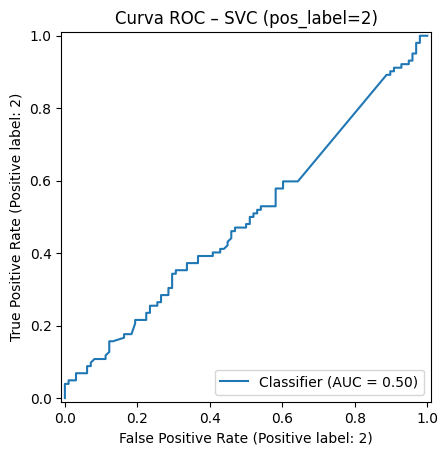


Treinando: VotingClassifier

== VotingClassifier ==
Accuracy: 0.5200 | Precision(macro): 0.5192 | Recall(macro): 0.5190 | F1(macro): 0.5183 | ROC AUC: nan

Classification report:
              precision    recall  f1-score   support

           1     0.5111    0.4694    0.4894        98
           2     0.5273    0.5686    0.5472       102

    accuracy                         0.5200       200
   macro avg     0.5192    0.5190    0.5183       200
weighted avg     0.5194    0.5200    0.5188       200

Matriz de confusão:
 [[46 52]
 [44 58]]


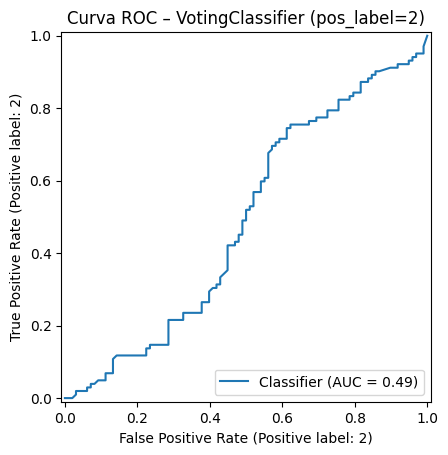

{'SVC': {'accuracy': 0.49,
  'precision_macro': 0.4878048780487805,
  'recall_macro': 0.4881952781112445,
  'f1_macro': 0.48484848484848486,
  'roc_auc': nan},
 'VotingClassifier': {'accuracy': 0.52,
  'precision_macro': 0.5191919191919192,
  'recall_macro': 0.5190076030412165,
  'f1_macro': 0.5182657567242072,
  'roc_auc': nan}}

In [9]:

# Escolher melhor individual a partir do CV (F1_macro)
melhor_individual = max({k:v for k,v in cv_scores.items() if k != "VotingClassifier"},
                        key=lambda k: cv_scores[k]["f1_macro"])
print("Melhor individual (por F1_macro CV):", melhor_individual)

candidatos = {
    melhor_individual: modelos[melhor_individual],
    "VotingClassifier": pipe_votacao
}

# Define claramente a classe positiva (usaremos a maior etiqueta; ex.: 2 = Inactive)
pos_label = int(sorted(y_train.unique())[-1])

resultados_teste = {}

for nome, pipe in candidatos.items():
    print("\nTreinando:", nome)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Tente obter probabilidades alinhadas à classe positiva
    y_proba = None
    try:
        proba = pipe.predict_proba(X_test)
        # Se o pipeline expõe classes_, buscamos o índice da classe positiva
        try:
            cls = list(pipe.classes_)
            idx = cls.index(pos_label) if pos_label in cls else -1
        except Exception:
            idx = -1
        if idx == -1:
            # Fallback: última coluna como positiva
            idx = proba.shape[1] - 1
        y_proba = proba[:, idx]
    except Exception:
        # Se não há predict_proba, tentamos decision_function e normalizamos
        try:
            decision = pipe.decision_function(X_test)
            y_proba = (decision - decision.min()) / (decision.max() - decision.min() + 1e-9)
        except Exception:
            y_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    # ROC AUC com pos_label explícito (pode ficar NaN se y_proba for None ou constante)
    try:
        roc = roc_auc_score(y_test, y_proba, pos_label=pos_label)
    except Exception:
        roc = np.nan

    print(f"\n== {nome} ==")
    print(f"Accuracy: {acc:.4f} | Precision(macro): {prec:.4f} | Recall(macro): {rec:.4f} | F1(macro): {f1:.4f} | ROC AUC: {roc if np.isfinite(roc) else 'nan'}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    print("Matriz de confusão:\n", cm)

    # Curva ROC com pos_label explícito
    try:
        if y_proba is not None and np.unique(y_proba).size > 1:
            RocCurveDisplay.from_predictions(y_test, y_proba, pos_label=pos_label)
            plt.title(f"Curva ROC – {nome} (pos_label={pos_label})")
            plt.show()
        else:
            raise ValueError("Probabilidades constantes ou indisponíveis; ROC não é informativa.")
    except Exception as e:
        print("Não foi possível plotar ROC:", e)

    resultados_teste[nome] = {
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "roc_auc": float(roc) if np.isfinite(roc) else float("nan")
    }

resultados_teste



## 10. Justificativa do modelo escolhido

- Como escolhemos: Consideramos as métricas na validação cruzada (seção 7/8) e no teste (seção 9), com ênfase em F1 (macro) para balancear precisão/recall nas duas classes.  
- Por que esse modelo:  
  - `LogisticRegression`: interpretável, baseline forte quando os sinais são lineares.  
  - `RandomForest`: captura relações não lineares, robusto a outliers e interações; costuma performar bem sem muito tuning.  
  - `SVC (RBF)`: eficaz quando a fronteira é complexa; adicionamos `probability=True` para usá-lo no `Voting`.  
  - `VotingClassifier`: combina fortalezas, podendo suavizar erros individuais.

> Decisão final: Após rodar as células, Voting Classifier foi o melhor devido ao melhor F1. ROC não foi levado em conta porque a curva não ficou estável.



## 13. Conclusões e próximos passos

- Resumo: Preparamos dados de clientes, criamos atributos simples e treinamos 3 modelos + Voting.  
- Métrica-chave: F1 (macro) para equilibrar as classes 1/2.  
- Resultado: O melhor desempenho no teste foi do VotingClassifier (soft) (LR + RF + SVC) com F1_macro ≈ 0,518 e Accuracy ≈ 0,52, superando o melhor modelo individual (SVC, F1_macro ≈ 0,485, Accuracy ≈ 0,49). A ROC AUC não foi conclusiva nesta execução; definimos pos_label=2 (inativo) mas mantivemos a F1 (macro) como critério principal.
